In [1]:
import numpy as np 
import pandas as pd 
import scipy.stats as stats
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import PowerTransformer


In [2]:
df=pd.read_csv("../../datasets/concrete_data.csv")

In [3]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [13]:
x=df.drop("Strength",axis="columns")
y=df["Strength"]

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

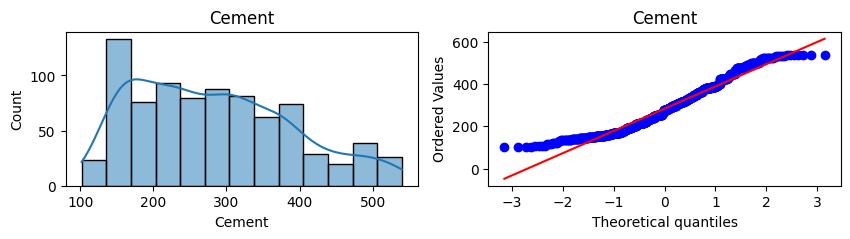

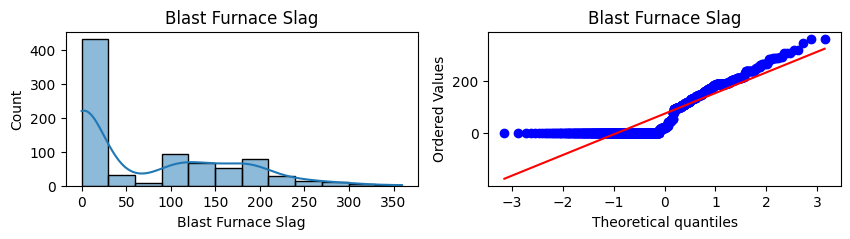

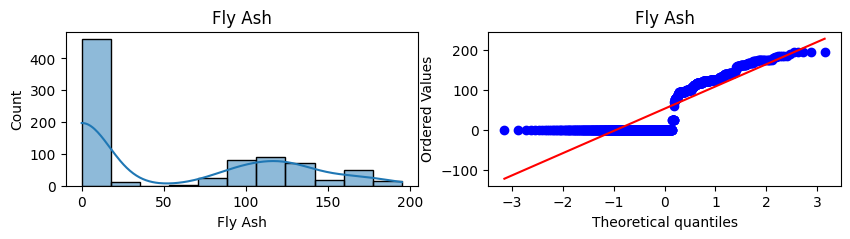

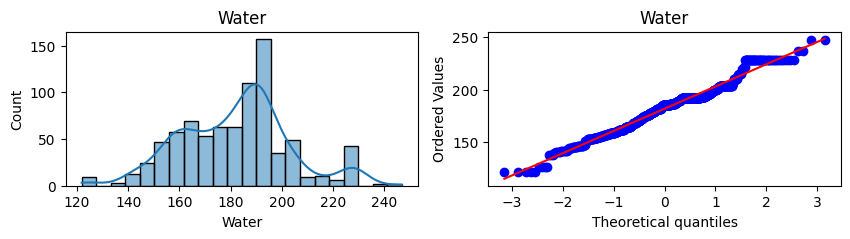

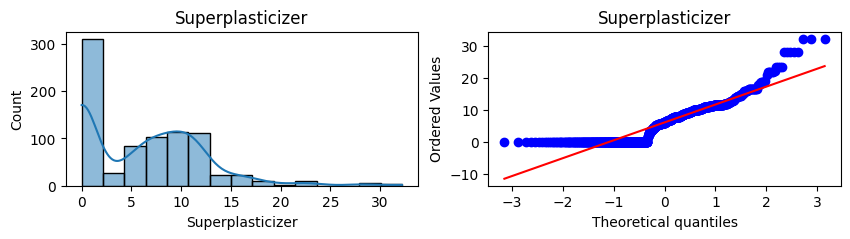

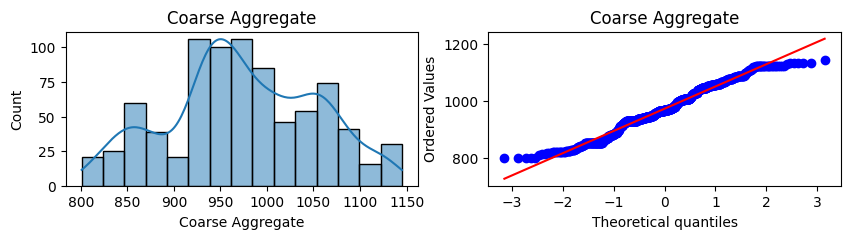

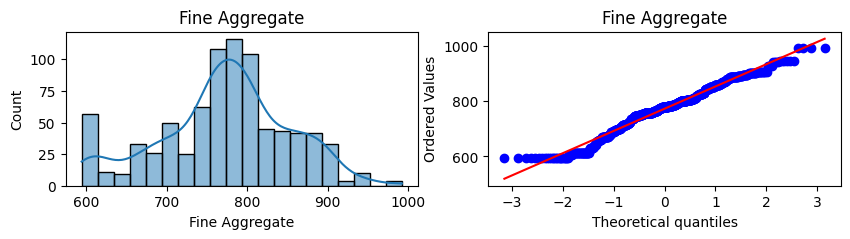

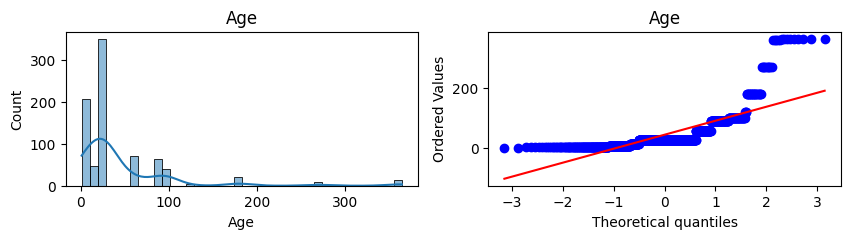

In [24]:
for col in x_train.columns:
    plt.figure(figsize=(10,2))
    plt.subplot(121)
    sns.histplot(x_train[col],kde="True")
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train[col],dist="norm",plot=plt)
    plt.title(col)
    plt.show()
    

In [29]:
lr=LinearRegression()
from sklearn.metrics import r2_score

In [30]:
lr.fit(x_train,y_train)
pred=lr.predict(x_test)
print("accuracy score",r2_score(y_test,pred))

accuracy score 0.6275531792314848


In [34]:
# cross validation
from sklearn.model_selection import cross_val_score
lr1=LinearRegression()
np.mean(cross_val_score(lr1,x,y,scoring="r2")) #here we don't use x_train & y_train as cross_val internally does spliting by itself

np.float64(0.4609940491662864)

In [37]:
# using transformation
tnf=PowerTransformer(method='box-cox')
x_train_tnf=tnf.fit_transform(x_train+0.000001)
x_test_tnf=tnf.transform(x_test+0.000001)
lm=pd.DataFrame({"cols":x_train.columns,"lambda_box_cox":tnf.lambdas_})


In [40]:
lr2=LinearRegression()
lr2.fit(x_train_tnf,y_train)
pred2=lr2.predict(x_test_tnf)
r2_score(y_test,pred2)

0.8047825008078886

In [42]:
##cross val
lr3=LinearRegression()
x_tnf=tnf.fit_transform(x+0.00001)
np.mean(cross_val_score(lr3,x_tnf,y,scoring="r2"))

np.float64(0.6668489649183531)

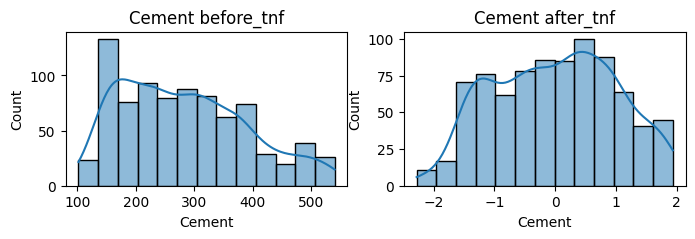

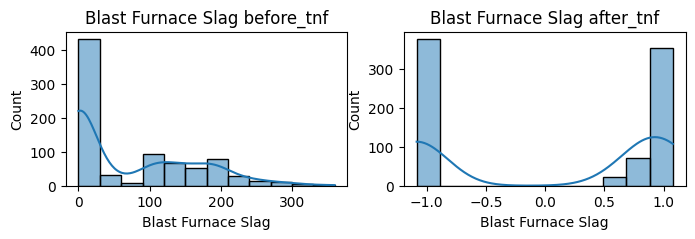

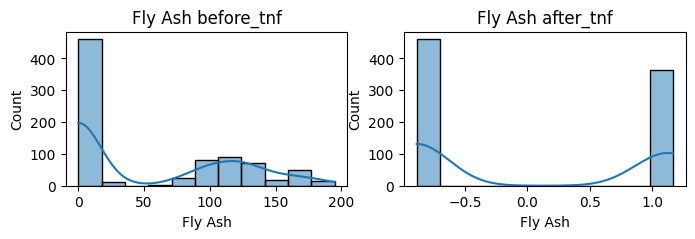

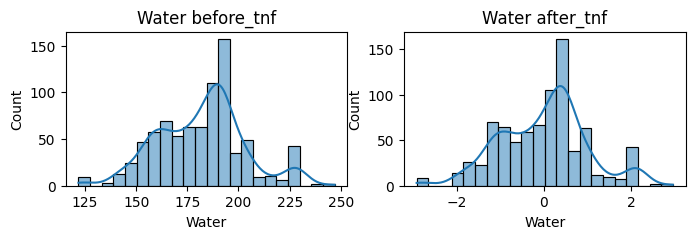

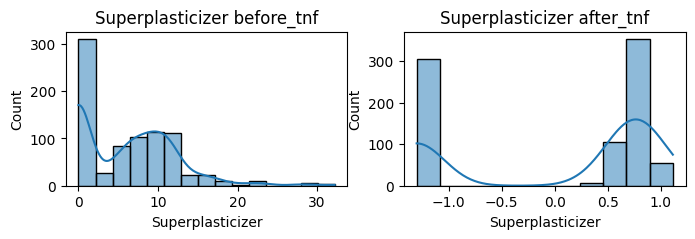

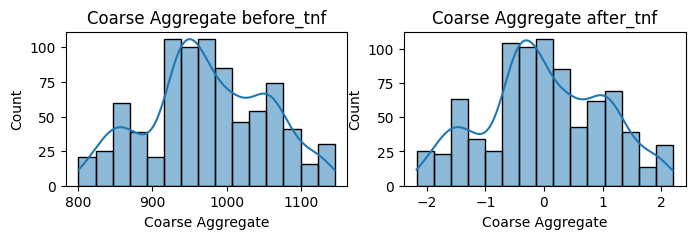

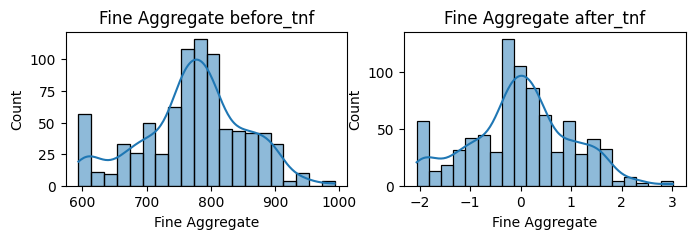

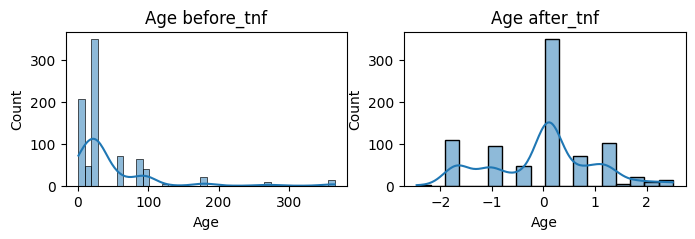

In [48]:
x_train_tnf=pd.DataFrame(x_train_tnf,columns=x_train.columns)
for col in x_train_tnf.columns:
    plt.figure(figsize=(8,2))
    plt.subplot(121)
    sns.histplot(x_train[col],kde="True")
    plt.title(col+" before_tnf")
    plt.subplot(122)
    sns.histplot(x_train_tnf[col],kde="True")
    plt.title(col+" after_tnf")
    plt.show()
    
    

In [49]:
tnf2=PowerTransformer()
x_train_tnf2=tnf2.fit_transform(x_train)
x_test_tnf2=tnf2.transform(x_test)
lm2=pd.DataFrame({"columnc":x_train.columns,"col_yeo_jhon_lmda":tnf2.lambdas_})

In [50]:
lm2

,columnc,col_yeo_jhon_lmda
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [51]:
lr4=LinearRegression()
lr4.fit(x_train_tnf2,y_train)
pred3=lr4.predict(x_test_tnf2)
r2_score(y_test,pred3)

0.8161906511066099

In [52]:
#cross val

lr5=LinearRegression()
x_tnf2=tnf2.fit_transform(x+0.00001)
np.mean(cross_val_score(lr5,x_tnf2,y,scoring="r2"))

np.float64(0.6834625833765646)

In [53]:
x_train_tnf2=pd.DataFrame(x_train_tnf2,columns=x_train.columns)

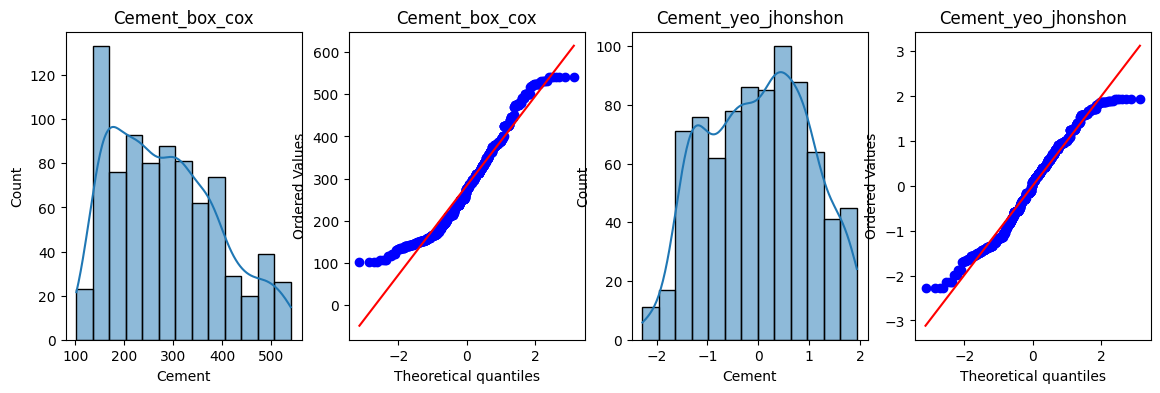

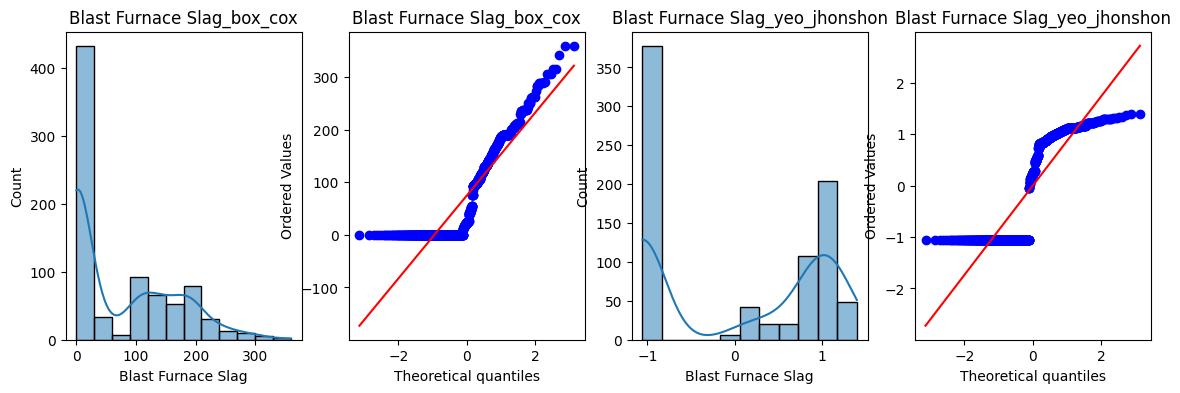

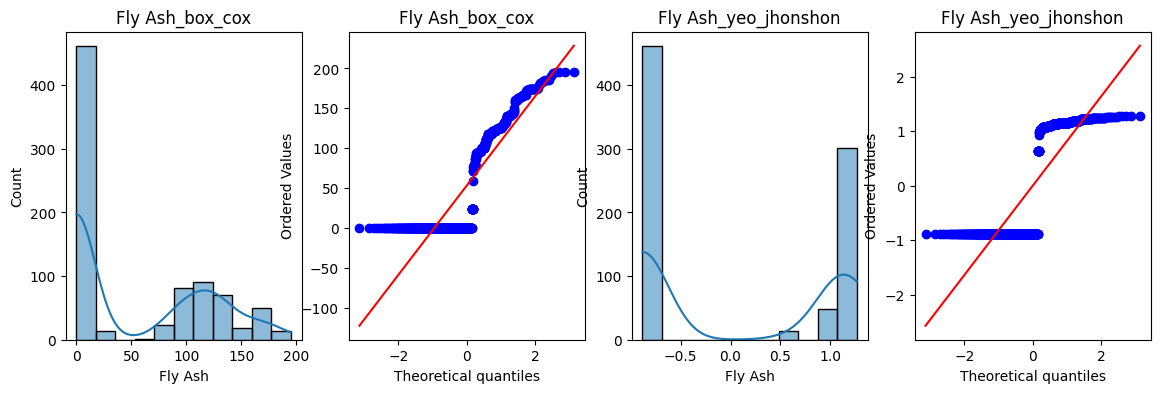

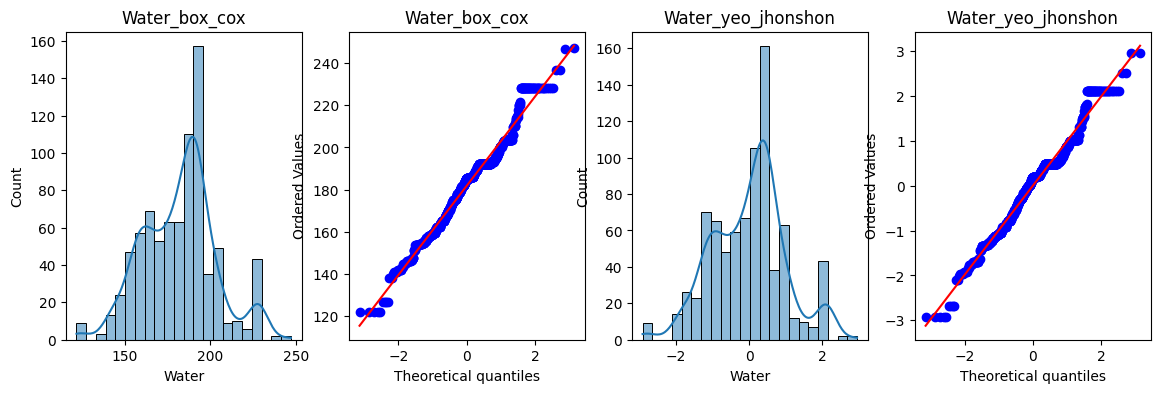

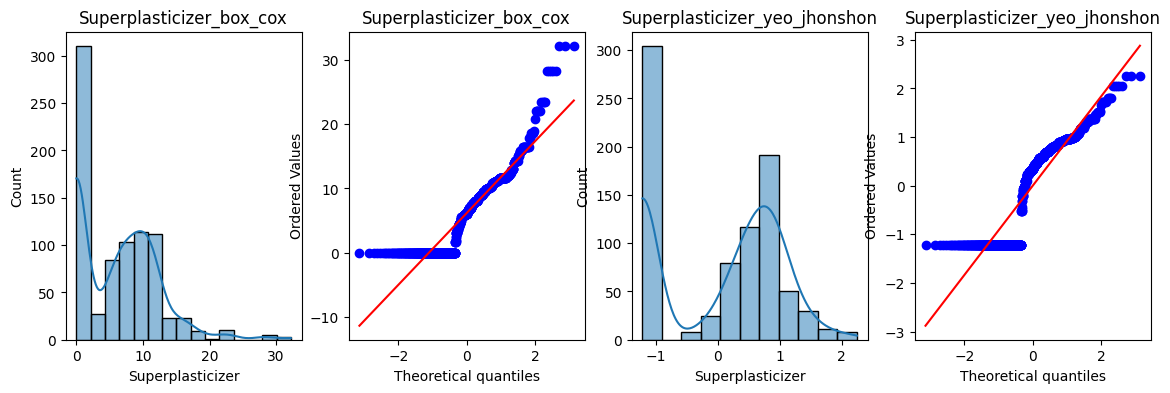

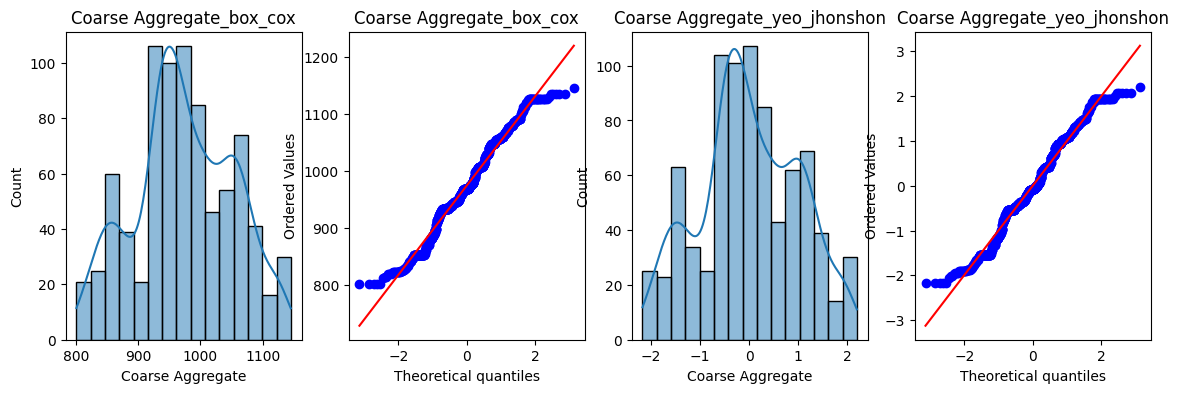

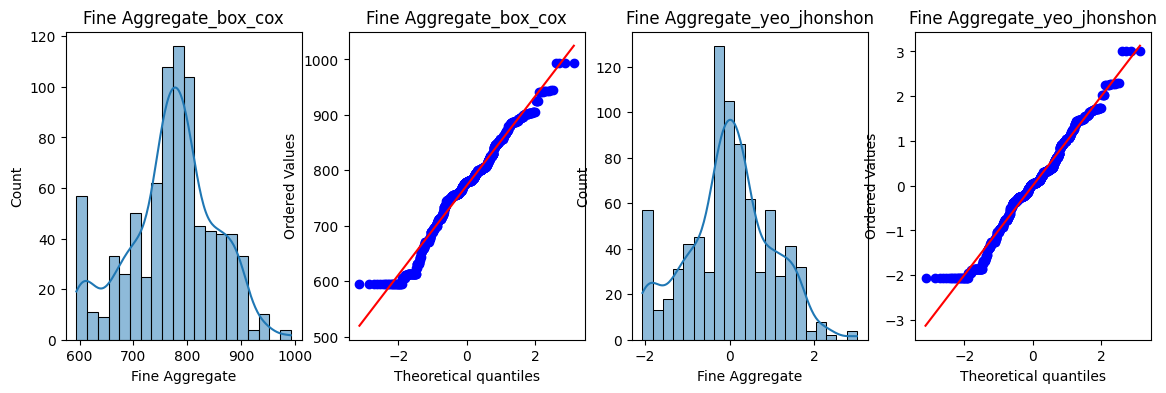

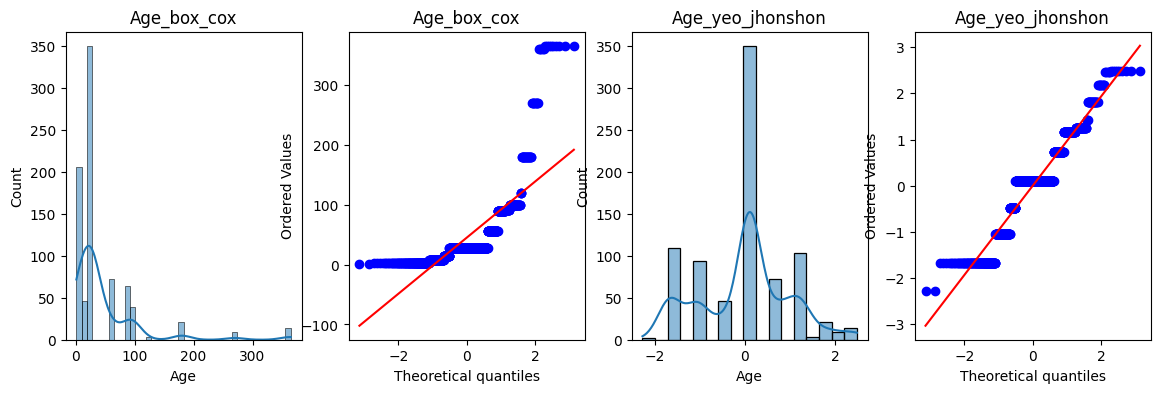

In [60]:
for col in x_train_tnf2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(141)
    sns.histplot(x_train[col],kde="True")
    plt.title(col+"_box_cox")

    plt.subplot(142)
    stats.probplot(x_train[col],dist="norm",plot=plt)
    plt.title(col+"_box_cox")

    plt.subplot(143)
    sns.histplot(x_train_tnf2[col],kde="True")
    plt.title(col+"_yeo_jhonshon")

    plt.subplot(144)
    stats.probplot(x_train_tnf2[col],dist="norm",plot=plt)
    plt.title(col+"_yeo_jhonshon")
    plt.show()

    
    